# Main Idea

The core ideas are as follows:

1. Starting from any vertex, if we recursively expand only with vertices that are adjacent to all vertices in the current set, then the search can always be extended until it reaches a maximal clique containing the starting vertex.

2. If a maximal clique $C=\{a,b,c,d\}$ has already been found, then no proper subset of $C$ can be maximal, and no other maximal clique can contain all of $C$. However, a new maximal clique may contain a proper subset of $C$ together with one or more new vertices outside $C$.

3. To avoid duplicate generation in maximal clique enumeration, the search must follow a fixed vertex ordering and extend partial cliques only according to that order.

## Example

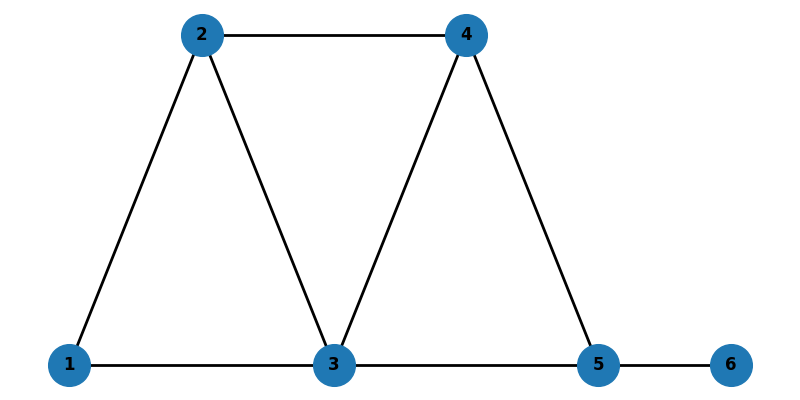

The maximal cliques are

$$
\{1,2,3\},\quad \{2,3,4\},\quad \{3,4,5\},\quad \{5,6\}.
$$

### 1. Expansion from a vertex reaches a maximal clique

Start from \(2\). We can expand

$$
\{2\}\rightarrow \{1,2\}\rightarrow \{1,2,3\}.
$$

Since no other vertex is adjacent to all vertices in \(\{1,2,3\}\), the set \(\{1,2,3\}\) is maximal.

### 2. A new maximal clique can only reuse a proper subset

After finding $C=\{1,2,3\}$, no proper subset of $C$ is maximal, since each such subset can be extended to $C$. Also, no other maximal clique can contain all of $C$. However, another maximal clique may contain a proper subset of $C$ together with new vertices; for example, $\{2,3,4\}$ reuses $\{2,3\} \subset C$.

### 3. Fixed ordering avoids duplicates

Using the order

$$
1<2<3<4<5<6,
$$

the clique $\{2,3,4\}$ is generated only through the path

$$
2\rightarrow 3\rightarrow 4,
$$

and not through other permutations such as $3\rightarrow 2\rightarrow 4$. Thus, each maximal clique is generated exactly once.

# Algorithm using an Example

<img src="pics/demo1.jpeg" style="width:300px; height:auto;">

## Canonical Ordering

Let us fix the canonical order to be the increasing order of vertex numbers. Then:

$$
N_0=\{1,2,3\},\quad N_1=\{2,3\},\quad N_2=\{3\}
$$

$$
N_3=\{4,5\},\quad N_4=\{5\},\quad N_5=\{6,7,8\}
$$

$$
N_6=\{7,8\},\quad N_7=\{8\},\quad N_8=\{9,10\}
$$

$$
N_9=\{10\},\quad N_{10}=\{11,12,13\},\quad N_{11}=\{12,13\}
$$

$$
N_{12}=\{13,14\},\quad N_{13}=\{14\},\quad N_{14}=\varnothing
$$

## Initial Expansion 

<img src="pics/algo_step_1.JPG" style="width:800px; height:auto;">


### First Reordering at Level 1

After finding the maximal clique $\{0,1,2,3\}$, we reorder as follows:

1. Skip all trees rooted at $\{1\}, \{2\}, and \{3\}$, since they can only generate subsets of $\{0,1,2,3\}$.

2. Add the relevant vertices of $\{0,1,2,3\}$ to the remaining trees:
   1. $N_4 \cap \{0,1,2,3\} = \{3\}$
   2. $N_5 \cap \{0,1,2,3\} = \{3\}$
   3. $N_x \cap \{0,1,2,3\} = \varnothing$ for $x \in \{6,7,8,9,10,11,12,13,14\}$

   Therefore, vertex $3$ is added to the trees rooted at $4$ and $5$.

3. Since there are no sibling trees at level 1, this reordering has no effect on sibling trees.

### Expanding Subtree 4

Now,

$$
N_4=\{3,5\}.
$$

**Effect of previously found maximal cliques**

No previously found maximal clique affects vertex \(4\), so the subtree remains unchanged.

<img src="pics/subtree 4.png" style="width:400px; height:auto;">

#### Reordering Subtree 4 at Level 2

After finding the maximal clique $\{3,4,5\}$, we reorder subtree $4$ as follows:

1. Skip all subtrees whose heads are $\{4,3\}$ or $\{4,5\}$. Hence, the subtree $\{4,5\}$ is skipped.
2. Since no other subtree exists under $4$, we do not need to add $\{3,5\}$ to any remaining neighbors.
3. The maximal clique $\{3,4,5\}$ will affect sibling trees (discussed later).

### Expanding Subtree 5

Now,

$$
N_5=\{3,6,7,8\}.
$$

**Effect of previously found maximal cliques**

The only previously found maximal clique containing vertex $5$ is $\{3,4,5\}$.

Its complement is

$$
C_1=\{0,1,2,6,7,8,9,10,11,12,13,14\}.
$$

So the updated neighbor set is

$$
N_5 = C_1 \cap N_5 = \{6,7,8\}.
$$

Hence, the subtrees under $5$ are $\{5,6\}, \{5,7\}, \{5,8\}$.

<img src="pics/subtree 5.jpeg" style="width:400px; height:auto;">

#### Reordering Subtree 5 at Level 2

After finding the maximal clique $\{5,6,7,8\}$, we reorder subtree $5$ as follows:

1. Skip all subtrees whose heads are $\{5,6\}$, $\{5,7\}$, and $\{5,8\}$. Hence, the subtrees $\{5,7\}$ and $\{5,8\}$ are skipped.
2. Since no other subtree exists under $5$, we do not need to add $\{6,7,8\}$ to any remaining neighbors.
3. The maximal clique $\{5,6,7,8\}$ will affect the sibling trees rooted at $6$, $6$, and $8$ (discussed later).

### Expanding Subtree 6

Now,

$$
N_6=\{7,8\}.
$$

**Effect of previously found maximal cliques**

The only previously found maximal clique containing vertex $6$ is $\{5,6,7,8\}$.

Its complement is

$$
C_1=\{0,1,2,3,4,9,10,11,12,13,14\}.
$$

Thus,

$$
N_6 = C_1 \cap N_6 = \varnothing.
$$

Therefore, subtree $6$ is skipped entirely.

### Expanding Subtree 7

Now,

$$
N_7=\{8\}.
$$

**Effect of previously found maximal cliques**

The only previously found maximal clique containing vertex $7$ is $\{5,6,7,8\}$.

Its complement is

$$
C_1=\{0,1,2,3,4,9,10,11,12,13,14\}.
$$

Thus,

$$
N_7 = C_1 \cap N_7 = \varnothing.
$$

Therefore, subtree $7$ is skipped entirely.

### Expanding Subtree 8

Now,

$$
N_8=\{9,10\}.
$$

**Effect of previously found maximal cliques**

The only previously found maximal clique containing vertex $8$ is $\{5,6,7,8\}$.

Its complement is

$$
C_1=\{0,1,2,3,4,9,10,11,12,13,14\}.
$$

Thus,

$$
N_8 = C_1 \cap N_8 = \{9,10\}.
$$

Hence, the subtrees under $8$ are $\{8,9\} and \{8,10\}$.

<img src="pics/subtree 8.jpeg" style="width:400px; height:auto;">

#### Reordering Subtree 8 at Level 2

After finding the maximal clique $\{8,9,10\}$, we reorder subtree $8$ as follows:

1. Skip all subtrees whose heads are $\{8,9\}$ and $\{8,10\}$. Hence, the subtree $\{8,9\}$ is skipped.
2. Since no other subtree exists under $8$, we do not need to add $\{9,10\}$ to any remaining neighbors.
3. The maximal clique $\{8,9,10\}$ will affect the sibling trees rooted at $9$ and $10$ (discussed later).

### Expanding Subtree 9

Now,

$$
N_9=\{10\}.
$$

**Effect of previously found maximal cliques**

The previously found maximal cliques containing vertex $9$ are $\{8,9,10\}$.

Its complement is

$$
C_1=\{0,1,2,3,4,5,6,7,11,12,13,14\}.
$$

Thus,

$$
N_9 = C_1 \cap N_9 = \varnothing.
$$

Therefore, subtree $9$ is skipped entirely.

### Expanding Subtree 10

Now,

$$
N_{10}=\{11,12,13\}.
$$

**Effect of previously found maximal cliques**

The only previously found maximal clique containing vertex $10$ is $\{8,9,10\}$.

Its complement is

$$
C_1=\{0,1,2,3,4,5,6,7,11,12,13,14\}.
$$

Thus,

$$
N_{10} = C_1 \cap N_{10} = \{11,12,13\}.
$$

Hence, the subtrees under $10$ are $\{10,11\}, \{10,12\}, \{10,13\}$.

<img src="pics/subtree 10.jpeg" style="width:400px; height:auto;">

#### Reordering Subtree 10 at Level 2

After finding the maximal clique $\{10,11,12,13\}$, we reorder subtree $10$ as follows:

1. Skip all subtrees whose heads are $\{10,11\}, \{10,12\}$, and $\{10,13\}$. Hence, the subtrees $\{10,12\}$ and $\{10,13\}$ are skipped.
2. Since no other subtree exists under $10$, we do not need to add $\{11,12,13\}$ to any remaining neighbors.
3. The maximal clique $\{10,11,12,13\}$ will affect the later sibling trees rooted at $11, 12$, and $13$ (discussed later).

### Expanding Subtree 11

Now,

$$
N_{11}=\{12,13\}.
$$

**Effect of previously found maximal cliques**

The only previously found maximal clique containing vertex $11$ is $\{10,11,12,13\}$.

Its complement is

$$
C_1=\{0,1,2,3,4,5,6,7,8,9,14\}.
$$

Thus,

$$
N_{11} = C_1 \cap N_{11} = \varnothing.
$$

Therefore, subtree $11$ is skipped entirely.

### Expanding Subtree 12

Now,

$$
N_{12}=\{13,14\}.
$$

**Effect of previously found maximal cliques**

The only previously found maximal clique containing vertex $12$ is $\{10,11,12,13\}$.

Its complement is

$$
C_1=\{0,1,2,3,4,5,6,7,8,9,14\}.
$$

Thus,

$$
N_{12} = C_1 \cap N_{12} = \{14\}.
$$

Hence, the subtree under \(12\) is \(\{12,14\}\).

<img src="pics/subtree 12.jpeg" style="width:400px; height:auto;">

After expansion, we find the maximal clique $\{12,13,14\}$.

1. There are no additional subtrees under $12$ to skip.
2. Since no other subtree exists under $12$, we do not need to add $\{13,14\}$ to any remaining neighbors.
3. The maximal clique $\{12,13,14\}$ will affect the later sibling trees rooted at $13$ and $14$ (discussed later).

### Expanding Subtree 13

Now,

$$
N_{13}=\{14\}.
$$

**Effect of previously found maximal cliques**

The previously found maximal cliques containing vertex $13$ are $\{10,11,12,13\}$ and $\{12,13,14\}$.

Their complements are

$$
C_1=\{0,1,2,3,4,5,6,7,8,9,14\}
$$

$$
C_2=\{0,1,2,3,4,5,6,7,8,9,10,11\}.
$$

Thus,

$$
N_{13} = C_1 \cap C_2 \cap N_{13} = \varnothing.
$$

Therefore, subtree $13$ is skipped entirely.

### Expanding Subtree 14

Now,

$$
N_{14}=\varnothing.
$$

Therefore, subtree $14$ is skipped entirely.

Total Checks : 59

Our checks: 30